In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
test=pd.read_csv("test_data.csv")
train=pd.read_csv("training_data.csv")

In [7]:
test.head()

,PatientID,Resp,PR Seq,RT Seq,VL-t0,CD4-t0
0,1,H,NCTCTATTAGATACAGGAGCAGATGACACAGTATTAGAAGARATGG...,CCTATTAGTCCTATTGAAACTGTACCAGTRAAATTAAAGCCAGGAA...,5.6,69
1,2,H,NCTCTATTAGATACAGGAGCAGATGATACAGTATTAGAAGAAATGA...,CCCATCAGTCCTATTGAAACTGTACCAGTAAAATTAAAGCCAGGAA...,5.3,119
2,3,H,GGGCAAATAAAGGAAGCTCTATTAGATACAGGAGCAGATGATACAG...,CCCATTAGTCCTATTGAAACTGTACCAGTAAAATTAAAGCCAGGAA...,5.7,41
3,4,H,GGGCAACTAAAGGAAGCTCTATTAGATACAGGAGCAGATGATACAG...,CCTATTAGTCCTATTGAAACTGTACCAGTAAAATTAAAGCCAGGAA...,5.2,48
4,5,H,GGGGGGCAACTAAAGGAAGCTCTATTAGATACAGGAGCAGATGATA...,CCCATTAGTCCTATTGAAACTGTACCAGTAAAATTAAAGCCAGGAA...,5.5,311


In [8]:
train.head()

,PatientID,Resp,PR Seq,RT Seq,VL-t0,CD4-t0
0,1,0,CCTCAAATCACTCTTTGGCAACGACCCCTCGTCCCAATAAGGATAG...,CCCATTAGTCCTATTGAAACTGTACCAGTAAAGCTAAAGCCAGGAA...,4.3,145
1,2,0,CCTCAAATCACTCTTTGGCAACGACCCCTCGTCGCAATAAAGATAG...,CCCATTAGTCCTATTGAAACTGTACCAGTAAAATTAAAGCCAGGAA...,3.6,224
2,3,0,CCTCAAATCACTCTTTGGCAACGACCCCTCGTCGCAATAAAGGTAG...,CCCATTAGTCCTATTGAAACTGTACCAGTAAAATTAAAGCCAGGAA...,3.2,1017
3,4,0,CCTCAAATCACTCTTTGGCAACGACCCCTCGTCGCAATAAGGATAG...,CCCATTAGTCCTATTGAAACTGTACCAGTAAAATTAAAGCCAGGAA...,5.7,206
4,5,0,CCTCAAATCACTCTTTGGCAACGACCCCTCGTCGCAGTAAAGATAG...,CCCATTAGTCCTATTGAAACTGTACCAGTAAAATTAAAGCCAGGAA...,3.5,572


<Axes: xlabel='Resp'>

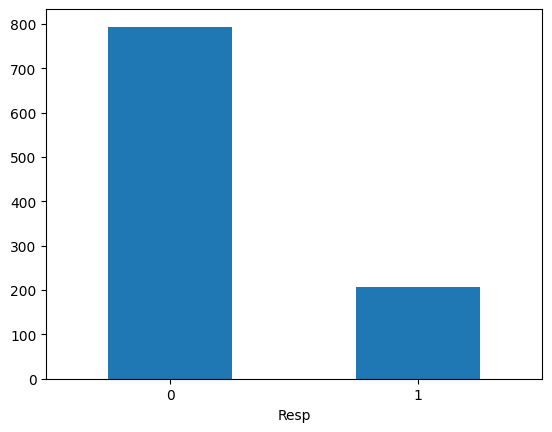

In [16]:
train['Resp'].value_counts().plot.bar(rot=0)

In [46]:
from sklearn import metrics
from sklearn.model_selection import train_test_split,GridSearchCV
import xgboost as xgb

In [47]:
x_cols = ['VL-t0', 'CD4-t0']
train_,test_ = train_test_split(train[x_cols + ['Resp']],test_size=0.33,random_state=42,stratify=train.Resp)

In [48]:
'train:',train_.Resp.value_counts() / len(train_),'test:',test_.Resp.value_counts() / len(test_)


params_grid = {
    'min_child_weight': [1, 5, 10],
    'gamma': [0.5, 1, 1.5, 2, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'max_depth': [3, 4, 5],
    'n_estimators': [100,300,600,1000]
}

xgc = xgb.XGBClassifier()
grid = GridSearchCV(xgc,params_grid,cv=3,verbose=1000,n_jobs=5)


In [49]:
grid.fit(train_[x_cols],train_.Resp)

ModuleNotFoundError: No module named '_posixsubprocess'